## Imports

In [1]:
import kagglehub

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve,auc, confusion_matrix, classification_report, roc_auc_score 

from xgboost import XGBClassifier

/home/orlandojunior/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Leitura dos dados

In [2]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e9')

print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e9


In [3]:
df_train = pd.read_csv(f'{path}/train.csv')
df_test = pd.read_csv(f'{path}/test.csv')
ids = df_test['id']

In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

## EDA

In [5]:
def preprocess_features(df_1: pd.DataFrame, df_2: pd.DataFrame, le: LabelEncoder) -> pd.DataFrame:
    df_cpy = pd.concat([df_1,df_2], axis=0, sort=False)
    
    df_cpy = df_cpy.drop(columns=['id'])
    df_cpy['Will_Buy_EV'] = le.fit_transform(df_cpy['Will_Buy_EV']) 
    
    df_cpy['Home_Charging_Possible'] = df_cpy['Home_Charging_Possible'].apply(lambda x: 1 if x == 'Yes' else 0)
    df_cpy['Subsidy_Available'] = df_cpy['Subsidy_Available'].apply(lambda x: 1 if x == 'Yes' else 0)
    
    df_cpy['Charging_possible'] =  df_cpy['Charging_Stations_Near_Work']/ (df_cpy['Charging_Stations_Near_Home'] + 1e-6)

    return df_cpy
     
    
    

In [6]:
le = LabelEncoder()
df = preprocess_features(df_train,df_test,le)

In [7]:
categorical_feauteres = df.select_dtypes(include=['str']).columns
categorical_feauteres

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Range_Anxiety_Level'], dtype='str')

In [8]:
for col in categorical_feauteres:
    print(f'{col} - {df_train[col].unique()}')

Gender - <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
City_Type - <StringArray>
['Suburban', 'Rural', 'Urban']
Length: 3, dtype: str
Current_Car_Type - <StringArray>
['Sedan', 'SUV', 'Hatchback', 'Truck']
Length: 4, dtype: str
Range_Anxiety_Level - <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str


In [9]:
numeric_features = df.select_dtypes(include=['number']).columns
numeric_features

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Home_Charging_Possible',
       'Subsidy_Available', 'Will_Buy_EV', 'Charging_possible'],
      dtype='str')

In [10]:
df[numeric_features].describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Home_Charging_Possible,Subsidy_Available,Will_Buy_EV,Charging_possible
count,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,955236.000000,9.552360e+05
mean,47.048667,84778.339428,32.158600,1.713667,4.957493,7.170108,2.935200,0.692140,0.628417,0.722252,3.407960e+05
std,12.872271,28641.665668,18.728653,0.729821,3.927379,5.186709,1.428645,0.461609,0.483228,0.894766,1.321172e+06
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,36.000000,67379.750000,17.200000,1.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,8.461538e-01
50%,47.000000,84889.000000,33.600000,2.000000,4.000000,6.000000,3.000000,1.000000,1.000000,0.000000,1.499999e+00
75%,58.000000,102753.000000,47.300000,2.000000,7.000000,10.000000,4.000000,1.000000,1.000000,2.000000,2.999997e+00
max,69.000000,188549.000000,103.900000,4.000000,14.000000,19.000000,5.000000,1.000000,1.000000,2.000000,1.900000e+07


<Axes: >

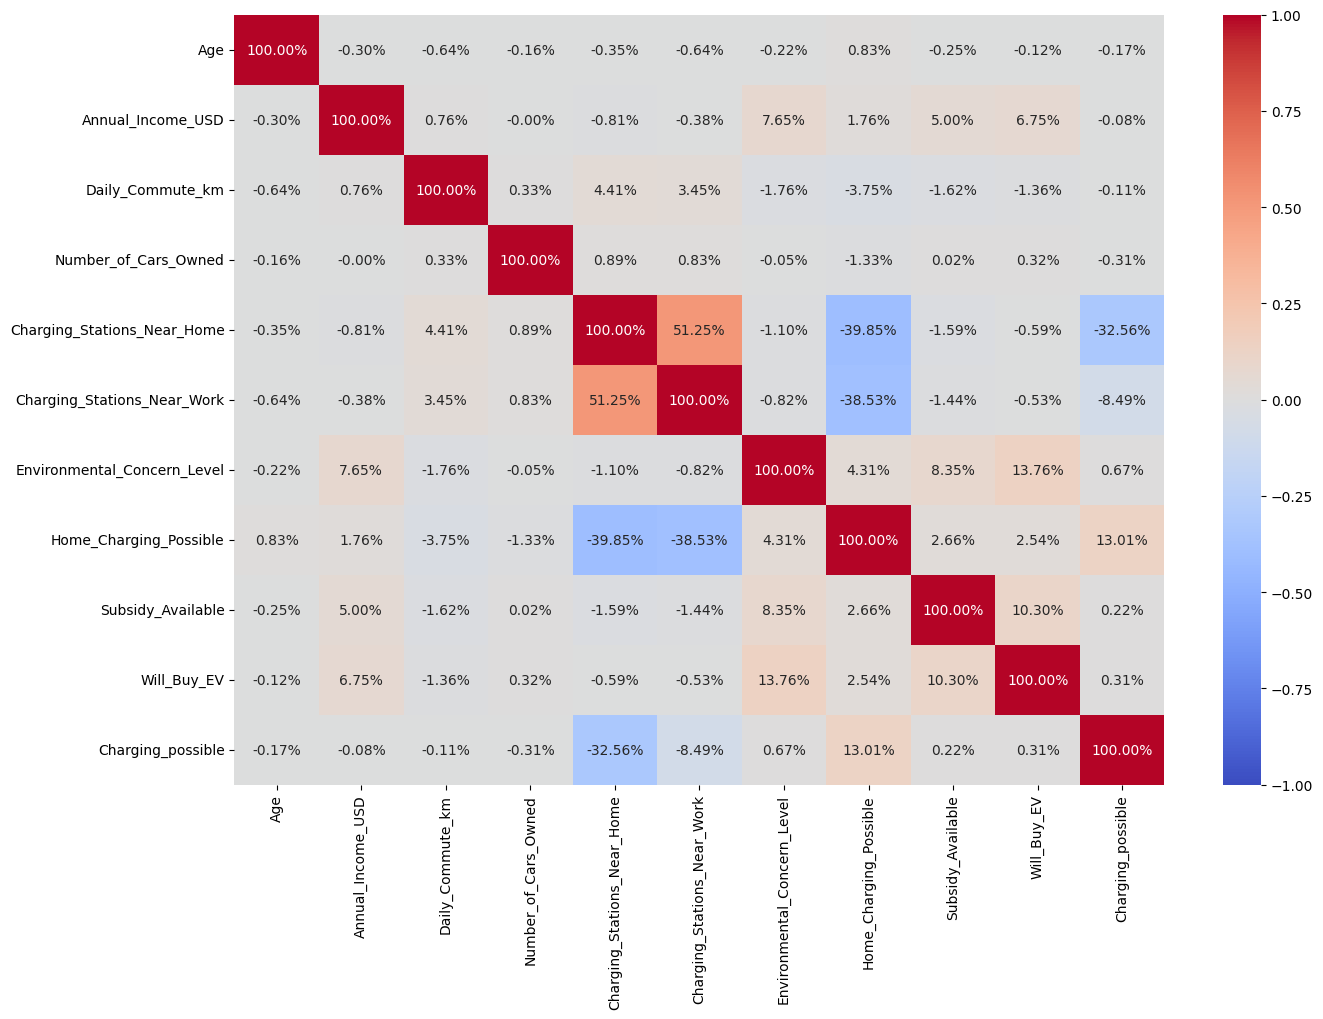

In [11]:
# Correlação

corr_matx = df[numeric_features].corr()
plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matx,
    vmin=-1,
    vmax=1,
    cmap='coolwarm',
    annot=True,
    fmt='.2%'
)

In [12]:
dados_corr = dict(corr_matx['Will_Buy_EV'].sort_values(ascending=False))
dados_corr

{'Will_Buy_EV': np.float64(1.0),
 'Environmental_Concern_Level': np.float64(0.13760997960273558),
 'Subsidy_Available': np.float64(0.10300844056893621),
 'Annual_Income_USD': np.float64(0.06751358932106559),
 'Home_Charging_Possible': np.float64(0.025444970776678958),
 'Number_of_Cars_Owned': np.float64(0.003192513088440595),
 'Charging_possible': np.float64(0.003132995629920319),
 'Age': np.float64(-0.0011597852198925297),
 'Charging_Stations_Near_Work': np.float64(-0.005340882879607196),
 'Charging_Stations_Near_Home': np.float64(-0.005916298791745011),
 'Daily_Commute_km': np.float64(-0.013601396222781722)}

In [13]:
for c,v in dados_corr.items():
    if v < 0.02:
        df = df.drop(columns=[f'{c}'])

df.info()

<class 'pandas.DataFrame'>
Index: 955236 entries, 0 to 286570
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Annual_Income_USD            955236 non-null  float64
 1   Environmental_Concern_Level  955236 non-null  float64
 2   Gender                       955236 non-null  str    
 3   City_Type                    955236 non-null  str    
 4   Current_Car_Type             955236 non-null  str    
 5   Home_Charging_Possible       955236 non-null  int64  
 6   Subsidy_Available            955236 non-null  int64  
 7   Range_Anxiety_Level          955236 non-null  str    
 8   Will_Buy_EV                  955236 non-null  int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 72.9 MB


## Pré-Processamento

In [14]:
features_to_scaler = df.select_dtypes(include=['number']).columns
features_to_scaler

Index(['Annual_Income_USD', 'Environmental_Concern_Level',
       'Home_Charging_Possible', 'Subsidy_Available', 'Will_Buy_EV'],
      dtype='str')

In [15]:
features_to_scaler = ['Annual_Income_USD', 'Environmental_Concern_Level',
       'Home_Charging_Possible', 'Subsidy_Available']

In [16]:
features_to_one_hot = df.select_dtypes(include=['str']).columns
features_to_one_hot

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Range_Anxiety_Level'], dtype='str')

In [17]:
preprocessing = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),features_to_scaler),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_to_one_hot)
    ],
    remainder='passthrough'
)

new_data = preprocessing.fit_transform(df)

names = preprocessing.get_feature_names_out()

new_df = pd.DataFrame(data=new_data,columns=names)
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 955236 entries, 0 to 955235
Data columns (total 18 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   num__Annual_Income_USD            955236 non-null  float64
 1   num__Environmental_Concern_Level  955236 non-null  float64
 2   num__Home_Charging_Possible       955236 non-null  float64
 3   num__Subsidy_Available            955236 non-null  float64
 4   cat__Gender_Female                955236 non-null  float64
 5   cat__Gender_Male                  955236 non-null  float64
 6   cat__Gender_Other                 955236 non-null  float64
 7   cat__City_Type_Rural              955236 non-null  float64
 8   cat__City_Type_Suburban           955236 non-null  float64
 9   cat__City_Type_Urban              955236 non-null  float64
 10  cat__Current_Car_Type_Hatchback   955236 non-null  float64
 11  cat__Current_Car_Type_SUV         955236 non-null  float64
 12 

## Divisão Treino Teste e validação

In [18]:
df_training = new_df[:len(df_train)]
df_testing = new_df[len(df_train):]

In [19]:
df_testing.info()

<class 'pandas.DataFrame'>
RangeIndex: 286571 entries, 668665 to 955235
Data columns (total 18 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   num__Annual_Income_USD            286571 non-null  float64
 1   num__Environmental_Concern_Level  286571 non-null  float64
 2   num__Home_Charging_Possible       286571 non-null  float64
 3   num__Subsidy_Available            286571 non-null  float64
 4   cat__Gender_Female                286571 non-null  float64
 5   cat__Gender_Male                  286571 non-null  float64
 6   cat__Gender_Other                 286571 non-null  float64
 7   cat__City_Type_Rural              286571 non-null  float64
 8   cat__City_Type_Suburban           286571 non-null  float64
 9   cat__City_Type_Urban              286571 non-null  float64
 10  cat__Current_Car_Type_Hatchback   286571 non-null  float64
 11  cat__Current_Car_Type_SUV         286571 non-null  float64

In [20]:
df_testing = df_testing.drop(columns=['remainder__Will_Buy_EV'])
df_testing.info()

<class 'pandas.DataFrame'>
RangeIndex: 286571 entries, 668665 to 955235
Data columns (total 17 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   num__Annual_Income_USD            286571 non-null  float64
 1   num__Environmental_Concern_Level  286571 non-null  float64
 2   num__Home_Charging_Possible       286571 non-null  float64
 3   num__Subsidy_Available            286571 non-null  float64
 4   cat__Gender_Female                286571 non-null  float64
 5   cat__Gender_Male                  286571 non-null  float64
 6   cat__Gender_Other                 286571 non-null  float64
 7   cat__City_Type_Rural              286571 non-null  float64
 8   cat__City_Type_Suburban           286571 non-null  float64
 9   cat__City_Type_Urban              286571 non-null  float64
 10  cat__Current_Car_Type_Hatchback   286571 non-null  float64
 11  cat__Current_Car_Type_SUV         286571 non-null  float64

In [21]:
X = df_training.drop(columns=['remainder__Will_Buy_EV'])
y = df_training['remainder__Will_Buy_EV']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42, shuffle=True,stratify=y_temp)

print(X_train.shape, X_val.shape, X_test.shape)

(468065, 17) (140420, 17) (60180, 17)


In [22]:
# Parâmetros modelo

params = {
    'n_estimators': 1000,
    'max_depth': 9,
    'eval_metric': 'auc',
    'learning_rate': 0.09918802139540925,
    'subsample': 0.6684329833808584,
    'colsample_bytree': 0.9151036654152414,
    'gamma': 0.14911870890152207,
    'reg_alpha': 0.10085071428350272,
    'reg_lambda': 0.6724424529145199,
    'min_child_weight': 2,
    'n_jobs': -1
}

In [23]:
skf = StratifiedKFold(n_splits=5)

results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

    xgb_cv = XGBClassifier(**params)
    xgb_cv.fit(X_tr, y_tr,
            verbose = False)

    y_pred = xgb_cv.predict(X_va)
    acc = roc_auc_score(y_va, y_pred)
    results.append(acc)
    print(f"Fold {fold}: roc_auc = {acc:.4f}")

Fold 1: roc_auc = 0.8028
Fold 2: roc_auc = 0.8029
Fold 3: roc_auc = 0.7991
Fold 4: roc_auc = 0.8011
Fold 5: roc_auc = 0.7998


In [24]:
np.mean(results)

np.float64(0.8011450517256506)

In [25]:
xgb_clf = XGBClassifier(**params,early_stopping_rounds=10)

xgb_clf.fit(X_train, y_train,                    
            eval_set = [(X_val,y_val)])

[0]	validation_0-auc:0.93859
[1]	validation_0-auc:0.93903
[2]	validation_0-auc:0.93924
[3]	validation_0-auc:0.93929
[4]	validation_0-auc:0.93934
[5]	validation_0-auc:0.93941
[6]	validation_0-auc:0.93940
[7]	validation_0-auc:0.93948
[8]	validation_0-auc:0.93948
[9]	validation_0-auc:0.93887
[10]	validation_0-auc:0.93956
[11]	validation_0-auc:0.93958
[12]	validation_0-auc:0.93963
[13]	validation_0-auc:0.93971
[14]	validation_0-auc:0.93972
[15]	validation_0-auc:0.93960
[16]	validation_0-auc:0.93965
[17]	validation_0-auc:0.93967
[18]	validation_0-auc:0.93966
[19]	validation_0-auc:0.93971
[20]	validation_0-auc:0.93973
[21]	validation_0-auc:0.93964
[22]	validation_0-auc:0.93967
[23]	validation_0-auc:0.93952
[24]	validation_0-auc:0.93957
[25]	validation_0-auc:0.93960
[26]	validation_0-auc:0.93975
[27]	validation_0-auc:0.93976
[28]	validation_0-auc:0.93978
[29]	validation_0-auc:0.93980
[30]	validation_0-auc:0.93982
[31]	validation_0-auc:0.93978
[32]	validation_0-auc:0.93981
[33]	validation_0-au

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9151036654152414
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import loa

In [26]:
y_pred_probs = xgb_clf.predict_proba(X_test)[:,1]
y_pred_probs

array([0.02269183, 0.558647  , 0.7076332 , ..., 0.32066864, 0.00122708,
       0.37501368], shape=(60180,), dtype=float32)

## Avaliar métricas

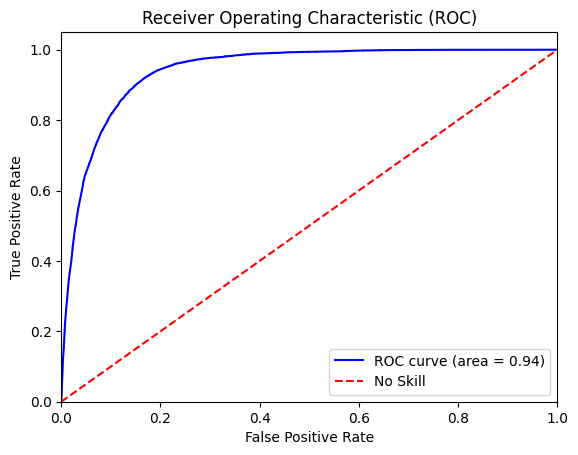

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(
    fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc
)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

In [28]:
y_pred = xgb_clf.predict(X_test)

In [29]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.93      0.95      0.94     49670
         1.0       0.73      0.66      0.69     10510

    accuracy                           0.90     60180
   macro avg       0.83      0.81      0.82     60180
weighted avg       0.89      0.90      0.90     60180



In [30]:
names = np.unique(le.inverse_transform(df_training['remainder__Will_Buy_EV'].astype(int)))
names

array(['No', 'Yes'], dtype=object)

<Axes: >

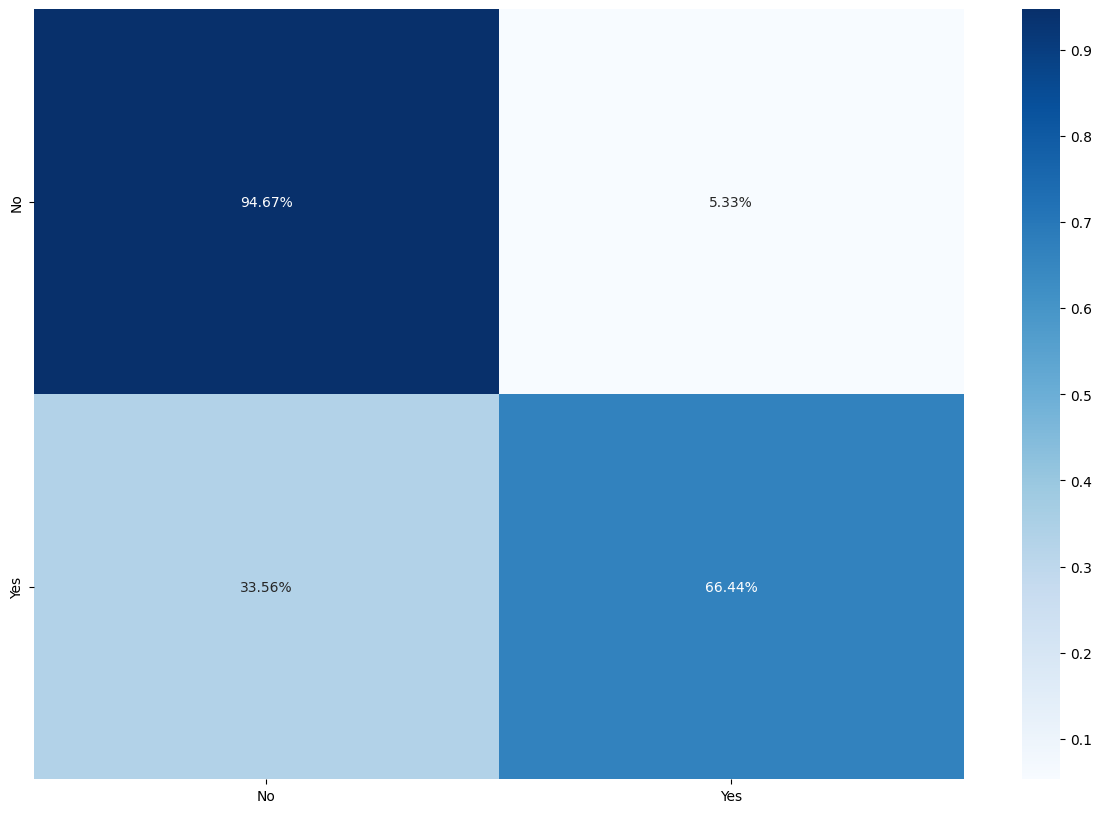

In [31]:
cfs_matrx = confusion_matrix(y_test,y_pred, normalize='true')
plt.figure(figsize=(15,10))

sns.heatmap(
    data=cfs_matrx,
    cmap='Blues',
    annot=True,
    fmt='.2%',
    yticklabels=names,
    xticklabels=names
)

## Submission

In [32]:
preds_final = xgb_clf.predict_proba(df_testing)[:,1]
preds_final

array([0.02215593, 0.02660389, 0.00608006, ..., 0.00236992, 0.00136885,
       0.00079589], shape=(286571,), dtype=float32)

In [33]:
df_result = pd.DataFrame({
    "id":ids,
    "Will_Buy_EV":preds_final
})

df_result.to_csv('submission.csv', index=False)